### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:
df=pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Display Columns

In [4]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [5]:
df.rename(columns={"NObeyesdad":"Obesity_Level"}, inplace=True)

In [6]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity_Level
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [8]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [9]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
Obesity_Level                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(24)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(2087, 17)

In [14]:
num_col = df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')

<Axes: >

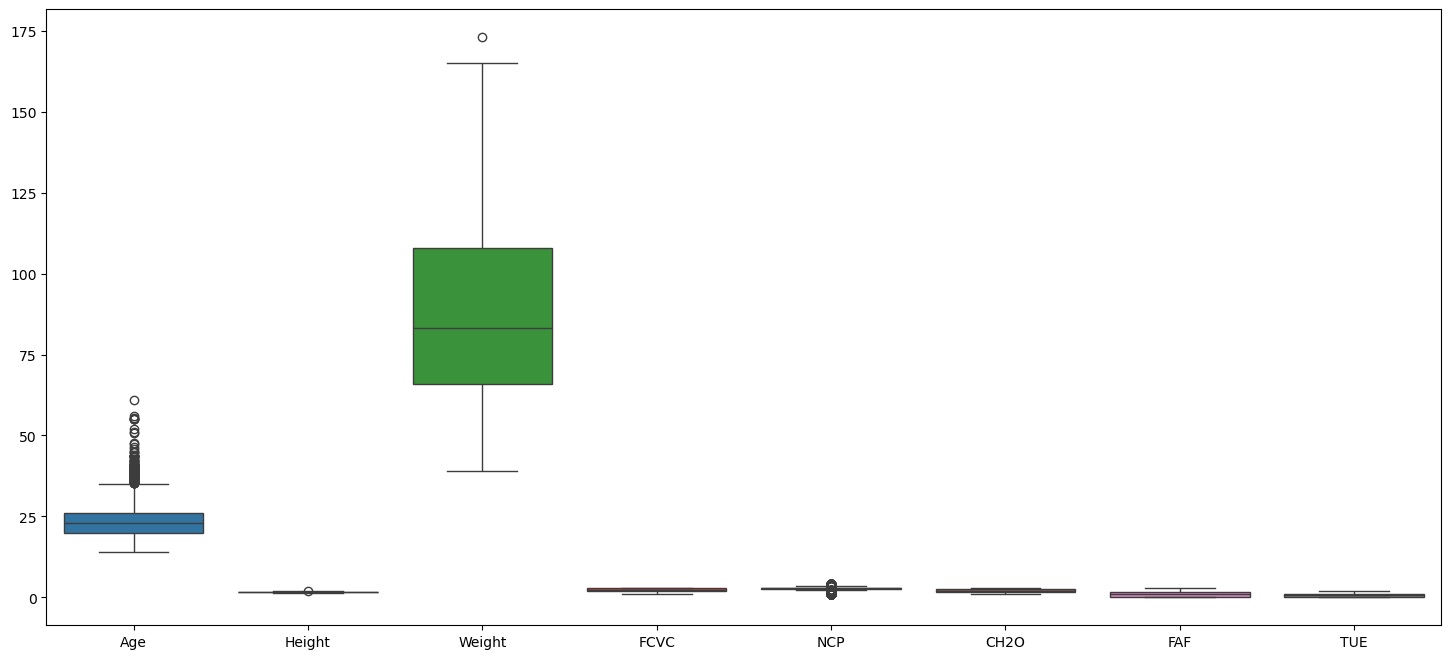

In [15]:
plt.figure(figsize=(18,8))
sns.boxplot(df)

In [16]:
cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for _ in range(4):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)

<Axes: >

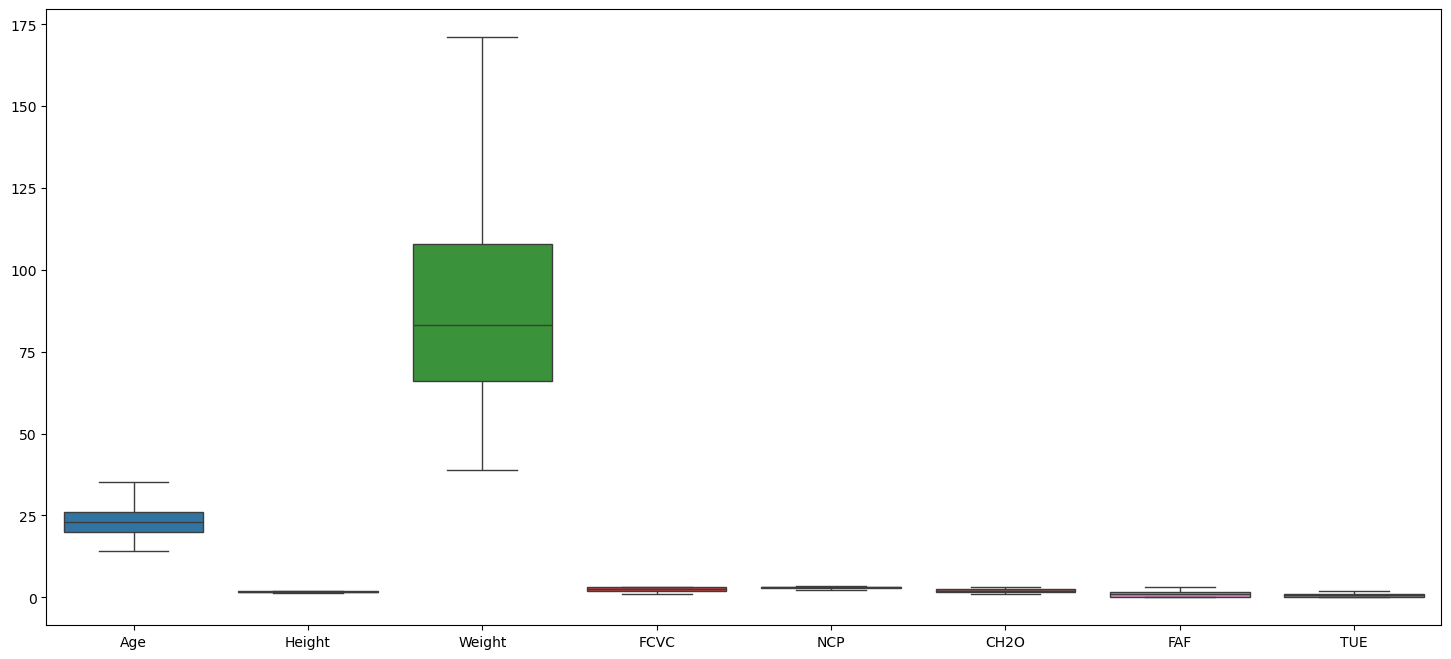

In [17]:
plt.figure(figsize=(18,8))
sns.boxplot(df)

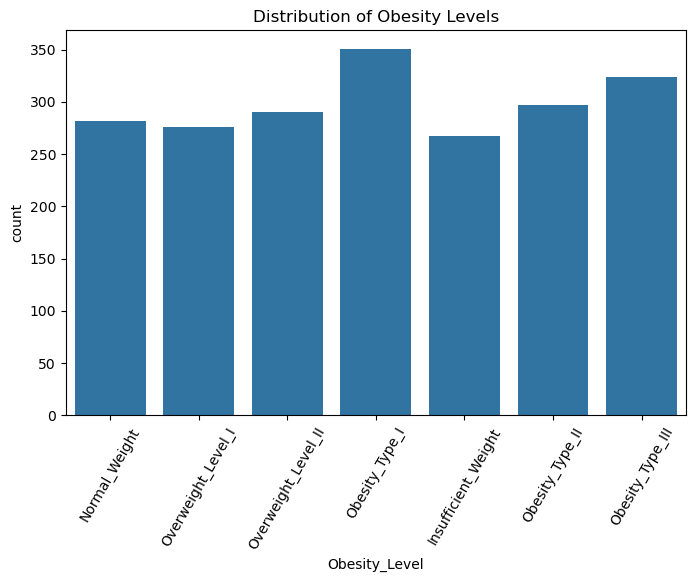

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x="Obesity_Level", data=df)
plt.xticks(rotation=60)
plt.title("Distribution of Obesity Levels")
plt.show()

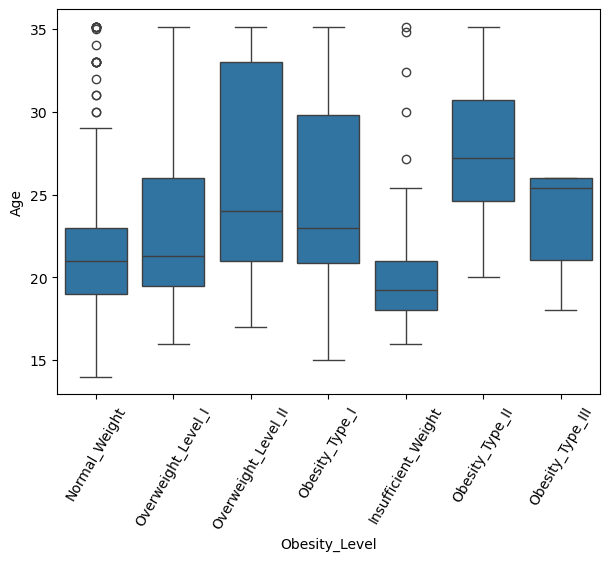

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Obesity_Level", y="Age", data=df)
plt.xticks(rotation=60)
plt.show()

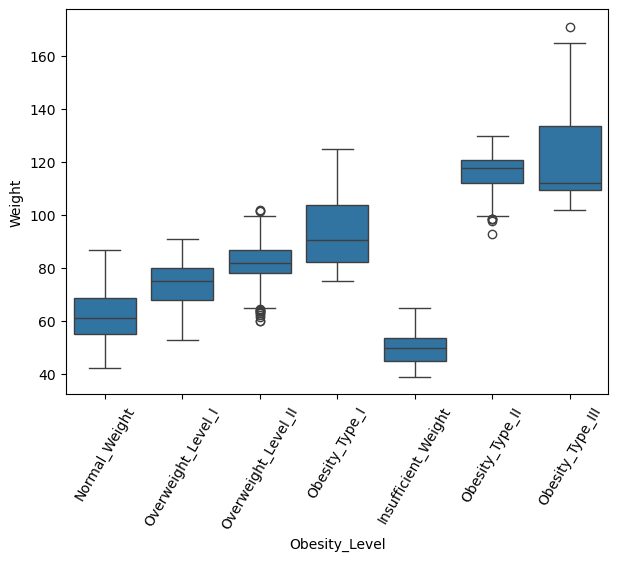

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Obesity_Level", y="Weight", data=df)
plt.xticks(rotation=60)
plt.show()

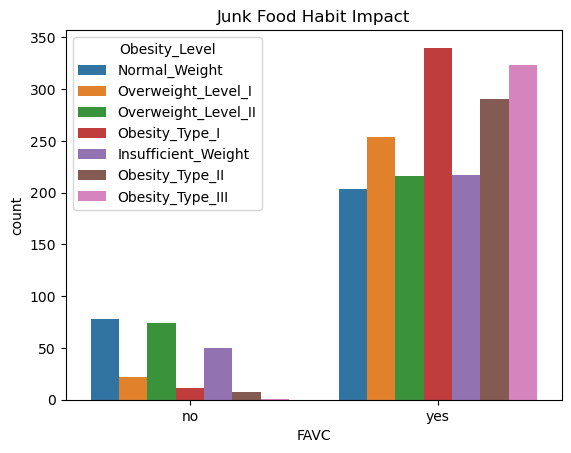

In [21]:
sns.countplot(x="FAVC", hue="Obesity_Level", data=df)
plt.title("Junk Food Habit Impact")
plt.show()

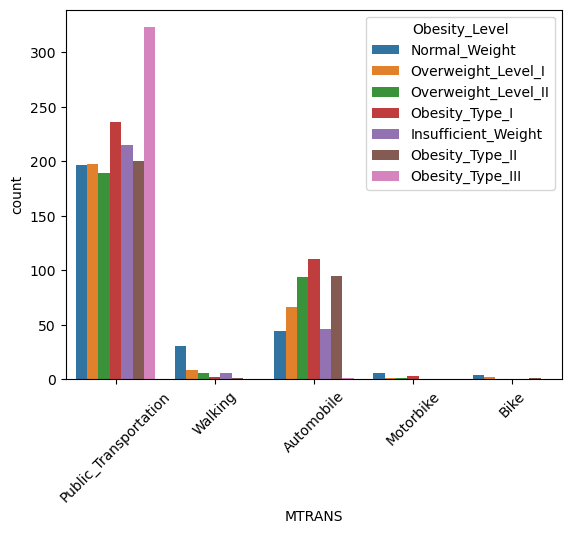

In [22]:
sns.countplot(x="MTRANS", hue="Obesity_Level", data=df)
plt.xticks(rotation=45)
plt.show()

In [23]:
df["SMOKE"].value_counts()

SMOKE
no     2043
yes      44
Name: count, dtype: int64

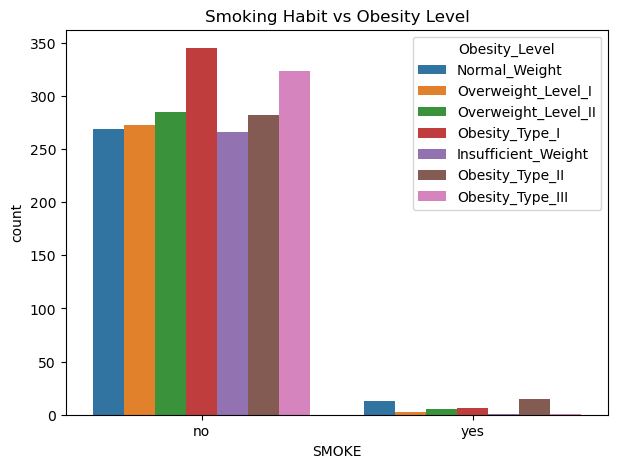

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(x="SMOKE", hue="Obesity_Level", data=df)
plt.title("Smoking Habit vs Obesity Level")
plt.show()

In [25]:
num_col = df.select_dtypes(include=['int64','float64']).columns
df_num = df[num_col]

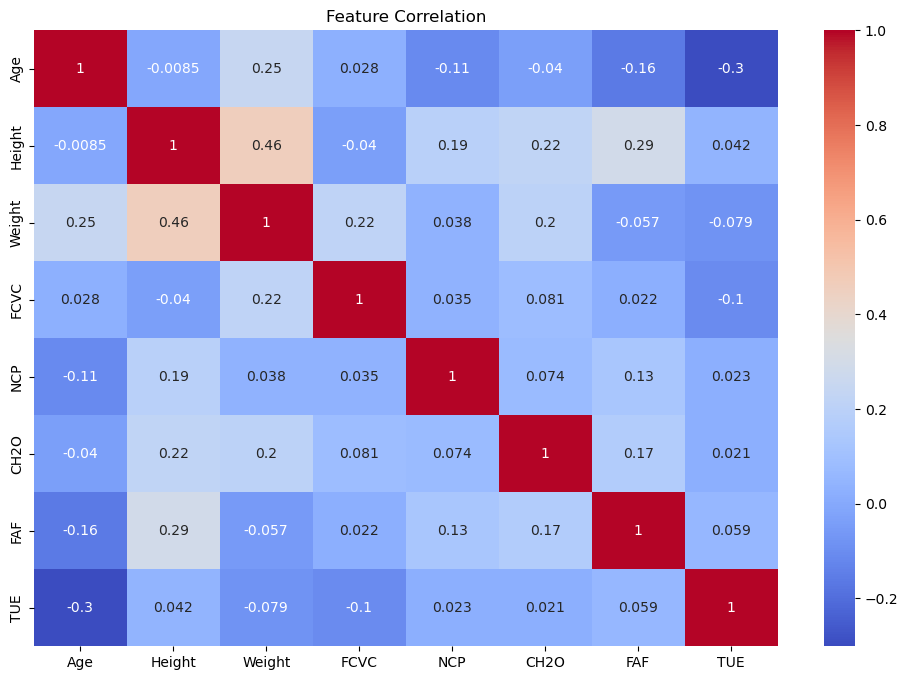

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_num.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation")
plt.show()

### Target Column

In [27]:
y = df[['Obesity_Level']]

In [28]:
y.head()

,Obesity_Level
0,Normal_Weight
1,Normal_Weight
2,Normal_Weight
3,Overweight_Level_I
4,Overweight_Level_II


In [29]:
X = df.drop(columns = ['Obesity_Level'],axis = 1)

In [30]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.000000,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.000000,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.000000,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.000000,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,2.243667,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


In [31]:
X.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS'],
      dtype='object')

In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   object 
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   object 
 5   FAVC                            2087 non-null   object 
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   object 
 9   SMOKE                           2087 non-null   object 
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   object 
 12  FAF                             2087 no

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler
fs = ColumnTransformer(transformers=[("t1",OrdinalEncoder(),[0,4,5,8,9,11,14,15]),
                                     ("t2",StandardScaler(),[1,2,3,6,7,10,12,13])])
X_transform = fs.fit_transform(X)

In [34]:
X_transform = pd.DataFrame(X_transform,columns = X.columns)

In [35]:
X_transform

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0.0,1.0,0.0,2.0,0.0,0.0,3.0,3.0,-0.556483,-0.887421,-0.873051,-0.788364,0.401080,-0.007810,-1.186977,0.554211
1,0.0,1.0,0.0,2.0,1.0,1.0,2.0,3.0,-0.556483,-1.960826,-1.178610,1.082164,0.401080,1.636552,2.328908,-1.090505
2,1.0,1.0,0.0,2.0,0.0,0.0,1.0,3.0,-0.179195,1.044709,-0.376517,-0.788364,0.401080,-0.007810,1.156947,0.554211
3,1.0,0.0,0.0,2.0,0.0,0.0,1.0,4.0,0.575380,1.044709,0.005432,1.082164,0.401080,-0.007810,1.156947,-1.090505
4,1.0,0.0,0.0,2.0,0.0,0.0,2.0,3.0,-0.367839,0.830028,0.112377,-0.788364,-1.720013,-0.007810,-1.186977,-1.090505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0,1.0,1.0,2.0,0.0,0.0,2.0,3.0,-0.560852,0.086480,1.701610,1.082164,0.401080,-0.454848,0.777546,0.400014
2083,0.0,1.0,1.0,2.0,0.0,0.0,2.0,3.0,-0.371057,0.492807,1.790773,1.082164,0.401080,0.000626,0.385081,-0.104876
2084,0.0,1.0,1.0,2.0,0.0,0.0,2.0,3.0,-0.268983,0.531686,1.788726,1.082164,0.401080,0.081303,0.470422,-0.027545
2085,0.0,1.0,1.0,2.0,0.0,0.0,2.0,3.0,0.077725,0.394762,1.775636,1.082164,0.401080,1.393744,0.148013,-0.126644


In [36]:
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X_transform,y)
mi = pd.Series(mi)
mi.index = X_transform.columns
mi.sort_values(ascending = False)

CH2O                              1.244629
CAEC                              0.571407
SMOKE                             0.414393
SCC                               0.411513
CALC                              0.304988
TUE                               0.299125
MTRANS                            0.284397
FAF                               0.226213
Gender                            0.211727
Weight                            0.162579
Age                               0.149792
FCVC                              0.102269
NCP                               0.078289
Height                            0.063720
FAVC                              0.053131
family_history_with_overweight    0.000296
dtype: float64

In [37]:
X = X.drop(columns=['family_history_with_overweight'],axis = 1)

In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  2087 non-null   object 
 1   Age     2087 non-null   float64
 2   Height  2087 non-null   float64
 3   Weight  2087 non-null   float64
 4   FAVC    2087 non-null   object 
 5   FCVC    2087 non-null   float64
 6   NCP     2087 non-null   float64
 7   CAEC    2087 non-null   object 
 8   SMOKE   2087 non-null   object 
 9   CH2O    2087 non-null   float64
 10  SCC     2087 non-null   object 
 11  FAF     2087 non-null   float64
 12  TUE     2087 non-null   float64
 13  CALC    2087 non-null   object 
 14  MTRANS  2087 non-null   object 
dtypes: float64(8), object(7)
memory usage: 260.9+ KB


In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [40]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1669, 15)
(1669, 1)
(418, 15)
(418, 1)


In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  2087 non-null   object 
 1   Age     2087 non-null   float64
 2   Height  2087 non-null   float64
 3   Weight  2087 non-null   float64
 4   FAVC    2087 non-null   object 
 5   FCVC    2087 non-null   float64
 6   NCP     2087 non-null   float64
 7   CAEC    2087 non-null   object 
 8   SMOKE   2087 non-null   object 
 9   CH2O    2087 non-null   float64
 10  SCC     2087 non-null   object 
 11  FAF     2087 non-null   float64
 12  TUE     2087 non-null   float64
 13  CALC    2087 non-null   object 
 14  MTRANS  2087 non-null   object 
dtypes: float64(8), object(7)
memory usage: 260.9+ KB


In [42]:
num_col = X.select_dtypes(include=['int64','float64']).columns
cat_col = X.select_dtypes(include=['object']).columns

In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_col),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_col)
])

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [45]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'], dtype='object'))])),
                ('model', KNeighborsClassifier())])

In [46]:
y_pred = pipe.predict(x_test)

In [47]:
y_train_pred = pipe.predict(x_train)

In [48]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuracy is Test",accuracy_score(y_pred,y_test))
print("Accuracy of Train",accuracy_score(y_train_pred,y_train))
print("Precision is ",precision_score(y_pred,y_test,average = 'macro'))
print("Recall is ",recall_score(y_pred,y_test,average = 'macro'))
print("f1_score is ",f1_score(y_pred,y_test,average = 'macro'))

Accuracy is Test 0.8205741626794258
Accuracy of Train 0.8987417615338527
Precision is  0.8096393253330323
Recall is  0.8036098589694863
f1_score is  0.7968053285354711


In [49]:
from sklearn.metrics import confusion_matrix, classification_report
con_mat=confusion_matrix(y_test,y_pred)
print(con_mat)
# Classification Report
report=classification_report(y_test,y_pred)
print(report)

[[52  3  0  0  0  0  2]
 [14 19  4  0  1 12  7]
 [ 0  0 64  3  0  0  0]
 [ 0  1  1 59  0  0  1]
 [ 0  0  0  0 68  0  0]
 [ 1  4  4  0  0 43  1]
 [ 1  2  6  4  1  2 38]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.91      0.83        57
      Normal_Weight       0.66      0.33      0.44        57
     Obesity_Type_I       0.81      0.96      0.88        67
    Obesity_Type_II       0.89      0.95      0.92        62
   Obesity_Type_III       0.97      1.00      0.99        68
 Overweight_Level_I       0.75      0.81      0.78        53
Overweight_Level_II       0.78      0.70      0.74        54

           accuracy                           0.82       418
          macro avg       0.80      0.81      0.80       418
       weighted avg       0.81      0.82      0.81       418



In [50]:
import pickle
with open("Obesity.pkl", "wb") as file:
    pickle.dump(pipe, file)
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


### Naive Bayes

In [50]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

nb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB())
])

In [51]:
nb_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'], dtype='object'))])),
                ('model', GaussianNB())])

In [52]:
y_pred_nb = nb_pipe.predict(x_test)
y_pred_nb_train = nb_pipe.predict(x_train)

In [53]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuracy is Test",accuracy_score(y_pred_nb,y_test))
print("Accuracy of Train",accuracy_score(y_pred_nb_train,y_train))
print("Precision is ",precision_score(y_pred_nb,y_test,average = 'macro'))
print("Recall is ",recall_score(y_pred_nb,y_test,average = 'macro'))
print("f1_score is ",f1_score(y_pred_nb,y_test,average = 'macro'))

Accuracy is Test 0.5287081339712919
Accuracy of Train 0.5110844817255842
Precision is  0.5030032099271545
Recall is  0.523774267024012
f1_score is  0.45431313688554137


### Decision Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

In [55]:
dt_pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [56]:
y_pred_dt = dt_pipe.predict(x_test)
y_pred_dt_train = dt_pipe.predict(x_train)

In [57]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuracy is Test",accuracy_score(y_pred_dt,y_test))
print("Accuracy of Train",accuracy_score(y_pred_dt_train,y_train))
print("Precision is ",precision_score(y_pred_dt,y_test,average = 'macro'))
print("Recall is ",recall_score(y_pred_dt,y_test,average = 'macro'))
print("f1_score is ",f1_score(y_pred_dt,y_test,average = 'macro'))

Accuracy is Test 0.7990430622009569
Accuracy of Train 0.8418214499700419
Precision is  0.7823903099874526
Recall is  0.7958273828061827
f1_score is  0.7828172211679124


### logistic Regression

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])df

In [69]:
lr_pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'], dtype='object'))])),
                ('model', LogisticRegression())])

In [70]:
y_pred_lr = lr_pipe.predict(x_test)
y_pred_lr_train = lr_pipe.predict(x_train)

In [71]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuracy is Test",accuracy_score(y_pred_lr,y_test))
print("Accuracy of Train",accuracy_score(y_pred_lr_train,y_train))
print("Precision is ",precision_score(y_pred_lr,y_test,average = 'macro'))
print("Recall is ",recall_score(y_pred_lr,y_test,average = 'macro'))
print("f1_score is ",f1_score(y_pred_lr,y_test,average = 'macro'))

Accuracy is Test 0.8875598086124402
Accuracy of Train 0.9017375674056322
Precision is  0.8822228195899927
Recall is  0.8833393232479878
f1_score is  0.8798345430966515


In [72]:
import pickle
with open("Obesity.pkl_Logistic_regression", "wb") as file:
    pickle.dump(lr_pipe, file)
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [73]:
models = {
    "KNN": pipe,
    "Naive Bayes": nb_pipe,
    "Decision Tree": dt_pipe,
    "Logistic Regression": lr_pipe
}

results = {}

for name, model in models.items():
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    results[name] = accuracy_score(y_test,pred)

print(results)

{'KNN': 0.8205741626794258, 'Naive Bayes': 0.5287081339712919, 'Decision Tree': 0.7990430622009569, 'Logistic Regression': 0.8875598086124402}
